# Presentation plots — VISOR + freqk results

Generates six slide-ready figures:

1. **Hero plot** — freqk works at favorable conditions (50× coverage, low repeat). Uses `results_rep.csv`.
2. **k-mer comparison at 10×** — effect of k at low coverage. Uses `results_rep.csv`.
3. **Coverage sweep (random positions)** — 31 random rep positions at 10×/20×/50×, no region split. Uses `results_rep.csv`.
4. **Summary heatmaps** — R² (end-to-end, non-detected imputed as AF=0) and detection rate across coverage × repeat level. Uses `results_var_selectedpos_w_repeatscore.csv`.
5. **Non-detectable bar chart** — failure mode by size × coverage × repeat. Uses `results_var_selectedpos_w_repeatscore.csv`.
6. **Continuous repeat-score diagnostic** — detection rate and mean |error| vs repeat score. Combines both CSVs, k=31.

Why two CSVs: `results_rep.csv` has 31 random rep positions (all rs<0.18, no high-repeat; k=30/31/32). `results_var_selectedpos_w_repeatscore.csv` has 6 hand-picked positions including centromere (high repeat, k=31 only), where ~50% of SVs are non-detectable.

**Why no low/moderate split on the rep_df plots:** `results_rep.csv` has 29 low-repeat positions but only 2 moderate-repeat positions (rs=0.12, 0.18), both just barely over the 0.10 threshold. The 3-way bucketing gives misleading R² comparisons; the continuous plot (plot 6) is the honest version.

All outputs go to `../plots/slide_*.pdf` and `../plots/slide_*.png` (300 DPI).

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

REP_CSV      = '../summaries/results_rep.csv'
SELPOS_CSV   = '../summaries/results_var_selectedpos_w_repeatscore.csv'
PLOT_DIR     = '../plots'
os.makedirs(PLOT_DIR, exist_ok=True)

rep_df = pd.read_csv(REP_CSV)
rep_df['detected'] = rep_df['af_alt'].notna()

sel_df = pd.read_csv(SELPOS_CSV)
if 'detected' not in sel_df.columns:
    sel_df['detected'] = sel_df['af_alt'].notna()

SIZE_ORDER   = ['100bp', '500bp', '1kb', '5kb', '10kb']
COV_ORDER    = [10, 20, 50]
REGION_ORDER = ['low repeat', 'moderate repeat', 'high repeat']
KMER_ORDER   = ['k30', 'k31', 'k32']
SIZE_COLORS  = dict(zip(SIZE_ORDER, sns.color_palette('viridis', len(SIZE_ORDER))))
COV_COLORS   = {10: '#d62728', 20: '#ff7f0e', 50: '#2ca02c'}

print(f'rep_df: {len(rep_df):,} rows, regions={rep_df["region_type"].unique().tolist()}, k={sorted(rep_df["k_label"].unique())}')
print(f'sel_df: {len(sel_df):,} rows, regions={sel_df["region_type"].unique().tolist()}, non-detected={(~sel_df["detected"]).sum()}')

rep_df: 2,849 rows, regions=['low repeat', 'moderate repeat'], k=['k30', 'k31', 'k32']
sel_df: 383 rows, regions=['moderate repeat', 'high repeat', 'low repeat'], non-detected=75


## Slide 6 — Hero plot (50× coverage, low repeat, k=31)

Purpose: open the results section by showing freqk works under favorable conditions.

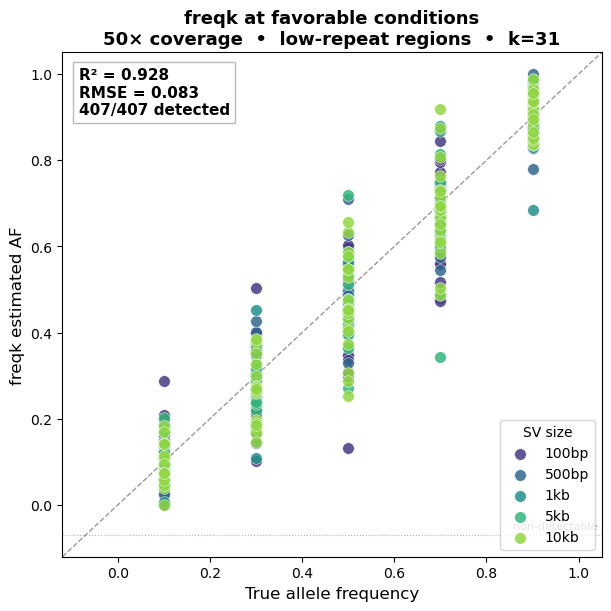

In [2]:
hero = rep_df[(rep_df['coverage']    == 50) &
              (rep_df['region_type'] == 'low repeat') &
              (rep_df['k_label']     == 'k31')].copy()

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
lo, hi, ND_Y = -0.12, 1.05, -0.07

det  = hero[hero['detected']]
ndet = hero[~hero['detected']]

for s in SIZE_ORDER:
    pts = det[det['size'] == s]
    ax.scatter(pts['freq_nominal'], pts['af_alt'],
               color=SIZE_COLORS[s], s=70, alpha=0.85,
               edgecolors='white', linewidths=0.4, zorder=3, label=s)
    pts = ndet[ndet['size'] == s]
    if not pts.empty:
        ax.scatter(pts['freq_nominal'], [ND_Y] * len(pts),
                   color=SIZE_COLORS[s], s=70, alpha=0.85,
                   edgecolors='white', linewidths=0.4, zorder=3)

ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.4)
ax.axhline(ND_Y, color='0.7', lw=0.8, ls=':')
ax.text(hi - 0.01, ND_Y + 0.01, 'non-detectable',
        ha='right', va='bottom', fontsize=8, color='0.5')

if len(det) >= 2:
    r2   = np.corrcoef(det['freq_nominal'], det['af_alt'])[0, 1] ** 2
    rmse = np.sqrt(((det['af_alt'] - det['freq_nominal']) ** 2).mean())
    ax.text(0.03, 0.97,
            f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\n{len(det)}/{len(hero)} detected',
            transform=ax.transAxes, va='top',
            fontsize=11, fontweight='bold',
            bbox=dict(fc='white', ec='0.7', alpha=0.9, pad=4))

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('True allele frequency', fontsize=12)
ax.set_ylabel('freqk estimated AF', fontsize=12)
ax.set_title('freqk at favorable conditions\n50× coverage  •  low-repeat regions  •  k=31',
             fontsize=13, fontweight='bold')
ax.legend(title='SV size', loc='lower right',
          fontsize=10, title_fontsize=10, frameon=True)
ax.tick_params(labelsize=10)

plt.savefig(f'{PLOT_DIR}/slide_hero_cov50_lowrepeat.pdf', bbox_inches='tight')
plt.savefig(f'{PLOT_DIR}/slide_hero_cov50_lowrepeat.png', bbox_inches='tight', dpi=300)
plt.show()

## Slide 10 — k-mer comparison at 10× coverage (reps 1–10)

Purpose: show whether k-mer length choice matters when coverage is tight.

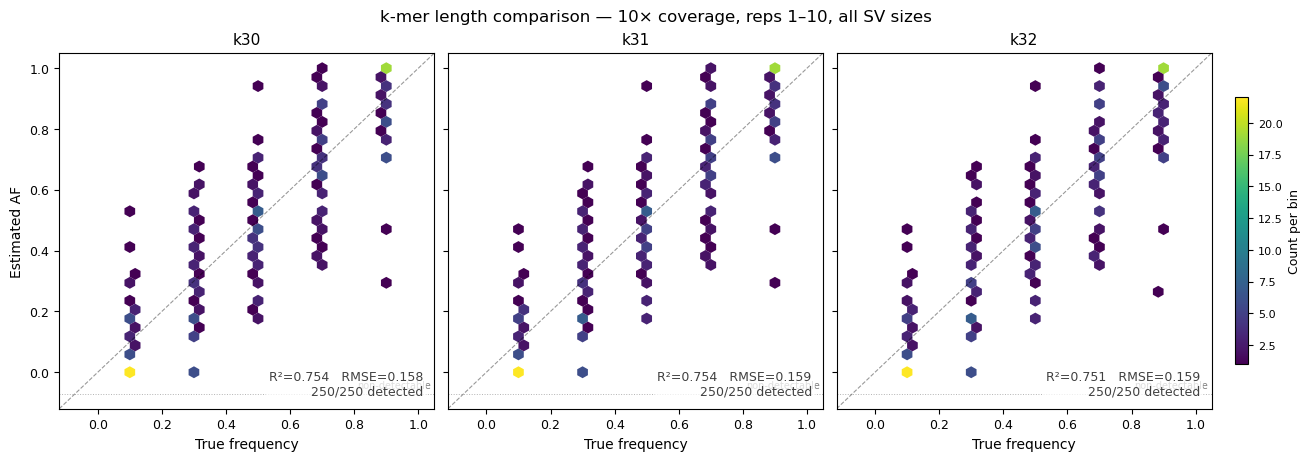

In [32]:
REPS_10 = [f'rep{i}' for i in range(1, 11)]
df10 = rep_df[(rep_df['coverage'] == 10) &
              (rep_df['rep_id'].isin(REPS_10))].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5),
                         sharex=True, sharey=True, constrained_layout=True)
lo, hi, ND_Y = -0.12, 1.05, -0.07

# Hexbin density per panel (shared colormap, consistent gridsize)
for ax, k in zip(axes, KMER_ORDER):
    sub  = df10[df10['k_label'] == k]
    det  = sub[sub['detected']]
    ndet = sub[~sub['detected']]

    hb = ax.hexbin(det['freq_nominal'], det['af_alt'],
                   gridsize=30, extent=(0, 1, 0, 1),
                   cmap='viridis', mincnt=1,
                   linewidths=0, zorder=2)

    if not ndet.empty:
        ax.scatter(ndet['freq_nominal'], [ND_Y] * len(ndet),
                   color='0.4', s=18, alpha=0.5, zorder=3)

    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4, zorder=4)
    ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':')
    ax.text(hi - 0.01, ND_Y + 0.01, 'non-detectable',
            ha='right', va='bottom', fontsize=7, color='0.5')

    n_tot, n_det = len(sub), len(det)
    if n_det >= 2:
        r2   = np.corrcoef(det['freq_nominal'], det['af_alt'])[0, 1] ** 2
        rmse = np.sqrt(((det['af_alt'] - det['freq_nominal']) ** 2).mean())
        ax.text(0.97, 0.03,
                f'R²={r2:.3f}   RMSE={rmse:.3f}\n{n_det}/{n_tot} detected',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=9, color='0.25',
                bbox=dict(fc='white', ec='none', alpha=0.75, pad=2))

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(k, fontsize=11)
    ax.set_xlabel('True frequency', fontsize=10)
    ax.tick_params(labelsize=9)

axes[0].set_ylabel('Estimated AF', fontsize=10)

# Single shared colorbar for density
cbar = fig.colorbar(hb, ax=axes, location='right', shrink=0.75, pad=0.02)
cbar.set_label('Count per bin', fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle('k-mer length comparison — 10× coverage, reps 1–10, all SV sizes',
             fontsize=12)

plt.savefig(f'{PLOT_DIR}/slide_kmer_cov10.pdf', bbox_inches='tight')
plt.savefig(f'{PLOT_DIR}/slide_kmer_cov10.png', bbox_inches='tight', dpi=300)
plt.show()

## Slide 7 — Coverage sweep across 31 random positions (no region split)

Uses `results_rep.csv`. Pools all 31 rep positions (which are mostly non-repetitive — 29 at rs<0.08 plus 2 at rs~0.12-0.18), k=31. Drops the low/moderate split because "moderate" only has 2 positions and would give a misleading comparison.

Purpose: show how freqk performs as coverage varies, holding the population of positions fixed.

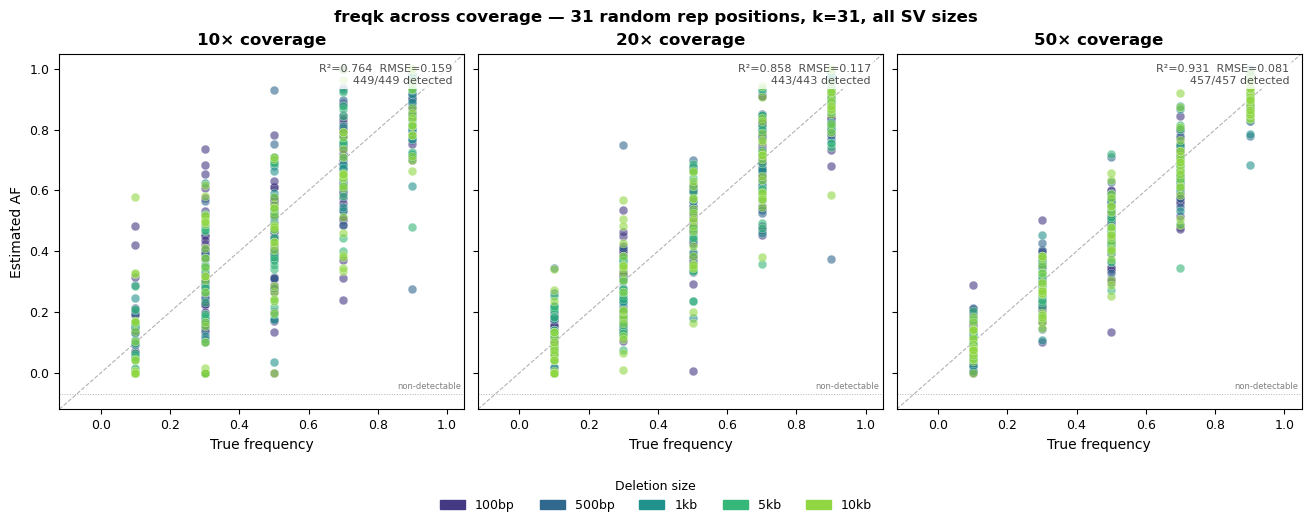

In [29]:
cov_df = rep_df[rep_df['k_label'] == 'k31'].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5),
                         sharex=True, sharey=True, constrained_layout=True)
lo, hi, ND_Y = -0.12, 1.05, -0.07

for ax, cov in zip(axes, COV_ORDER):
    sub  = cov_df[cov_df['coverage'] == cov]
    det  = sub[sub['detected']]
    ndet = sub[~sub['detected']]

    for s in SIZE_ORDER:
        pts = det[det['size'] == s]
        if not pts.empty:
            ax.scatter(pts['freq_nominal'], pts['af_alt'],
                       color=SIZE_COLORS[s], s=40, alpha=0.6,
                       edgecolors='white', linewidths=0.3, zorder=3)
        pts = ndet[ndet['size'] == s]
        if not pts.empty:
            ax.scatter(pts['freq_nominal'], [ND_Y] * len(pts),
                       color=SIZE_COLORS[s], s=40, alpha=0.6,
                       edgecolors='white', linewidths=0.3, zorder=3)

    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.3)
    ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':')
    ax.text(hi - 0.01, ND_Y + 0.01, 'non-detectable',
            ha='right', va='bottom', fontsize=6, color='0.5')

    n_tot, n_det = len(sub), len(det)
    if n_det >= 2:
        r2   = np.corrcoef(det['freq_nominal'], det['af_alt'])[0, 1] ** 2
        rmse = np.sqrt(((det['af_alt'] - det['freq_nominal']) ** 2).mean())
        ax.text(0.97, 0.97,
                f'R²={r2:.3f}  RMSE={rmse:.3f}\n{n_det}/{n_tot} detected',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='0.3',
                bbox=dict(fc='white', ec='none', alpha=0.8, pad=2))

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f'{cov}× coverage', fontsize=12, fontweight='bold')
    ax.set_xlabel('True frequency', fontsize=10)
    ax.tick_params(labelsize=9)

axes[0].set_ylabel('Estimated AF', fontsize=10)

size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
fig.legend(handles=size_patches, title='Deletion size',
           loc='lower center', ncol=len(SIZE_ORDER),
           fontsize=9, title_fontsize=9,
           bbox_to_anchor=(0.5, -0.15), frameon=False)

fig.suptitle('freqk across coverage — 31 random rep positions, k=31, all SV sizes',
             fontsize=12, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/slide_coverage_sweep.pdf', bbox_inches='tight')
plt.savefig(f'{PLOT_DIR}/slide_coverage_sweep.png', bbox_inches='tight', dpi=300)
plt.show()

## Slide 12 — Summary heatmaps: R² (end-to-end) + detection rate

Uses `results_var_selectedpos_w_repeatscore.csv` because it includes the high-repeat centromere positions where detection fails. k=31 only.

**R² is end-to-end**: non-detected SVs are imputed as AF=0 (what downstream analysis sees when freqk returns nothing), so the ~50% miss rate at high-repeat positions properly tanks R² there. The detection-rate panel makes the miss rate explicit.

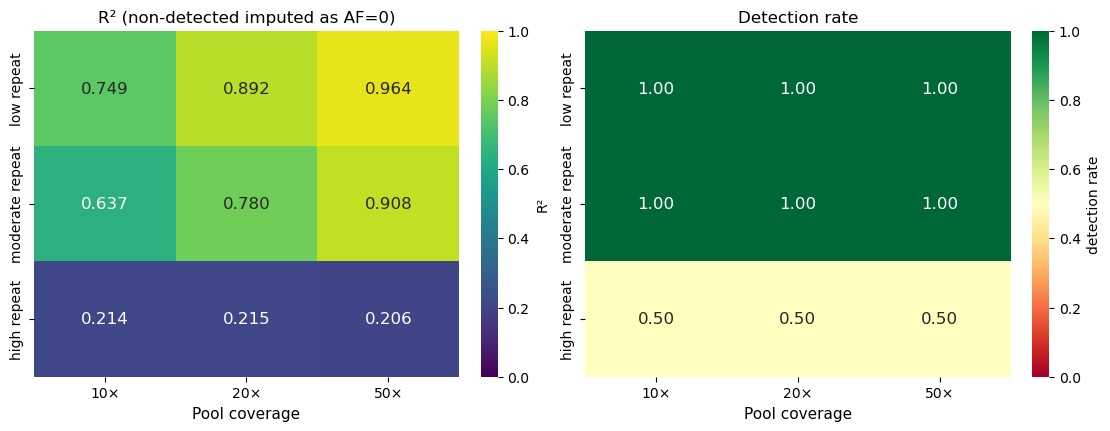

In [11]:
df = sel_df.copy()
# Impute non-detected AF as 0 — what downstream sees when freqk returns nothing.
# This gives end-to-end R² that properly penalizes the high-repeat miss rate.
df['af_alt_imputed'] = df['af_alt'].fillna(0.0)

r2_mat  = np.full((len(REGION_ORDER), len(COV_ORDER)), np.nan)
det_mat = np.full((len(REGION_ORDER), len(COV_ORDER)), np.nan)

for i, r in enumerate(REGION_ORDER):
    for j, c in enumerate(COV_ORDER):
        sub = df[(df['region_type'] == r) & (df['coverage'] == c)]
        if len(sub) >= 2 and sub['freq_nominal'].nunique() >= 2:
            corr = np.corrcoef(sub['freq_nominal'], sub['af_alt_imputed'])[0, 1]
            if not np.isnan(corr):
                r2_mat[i, j] = corr ** 2
        if len(sub):
            det_mat[i, j] = sub['detected'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

sns.heatmap(r2_mat, annot=True, fmt='.3f',
            xticklabels=[f'{c}×' for c in COV_ORDER], yticklabels=REGION_ORDER,
            cmap='viridis', vmin=0, vmax=1, ax=axes[0],
            cbar_kws={'label': 'R²'},
            annot_kws={'fontsize': 12})
axes[0].set_title('R² (non-detected imputed as AF=0)', fontsize=12)
axes[0].set_xlabel('Pool coverage', fontsize=11)
axes[0].set_ylabel('')

sns.heatmap(det_mat, annot=True, fmt='.2f',
            xticklabels=[f'{c}×' for c in COV_ORDER], yticklabels=REGION_ORDER,
            cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1],
            cbar_kws={'label': 'detection rate'},
            annot_kws={'fontsize': 12})
axes[1].set_title('Detection rate', fontsize=12)
axes[1].set_xlabel('Pool coverage', fontsize=11)
axes[1].set_ylabel('')


plt.savefig(f'{PLOT_DIR}/slide_summary_heatmaps.pdf', bbox_inches='tight')
plt.savefig(f'{PLOT_DIR}/slide_summary_heatmaps.png', bbox_inches='tight', dpi=300)
plt.show()

## Slide 13 — Non-detectable bar chart

Uses `results_var_selectedpos_w_repeatscore.csv`. Shows fraction of SVs that freqk fails to detect, broken out by size × coverage × repeat level.

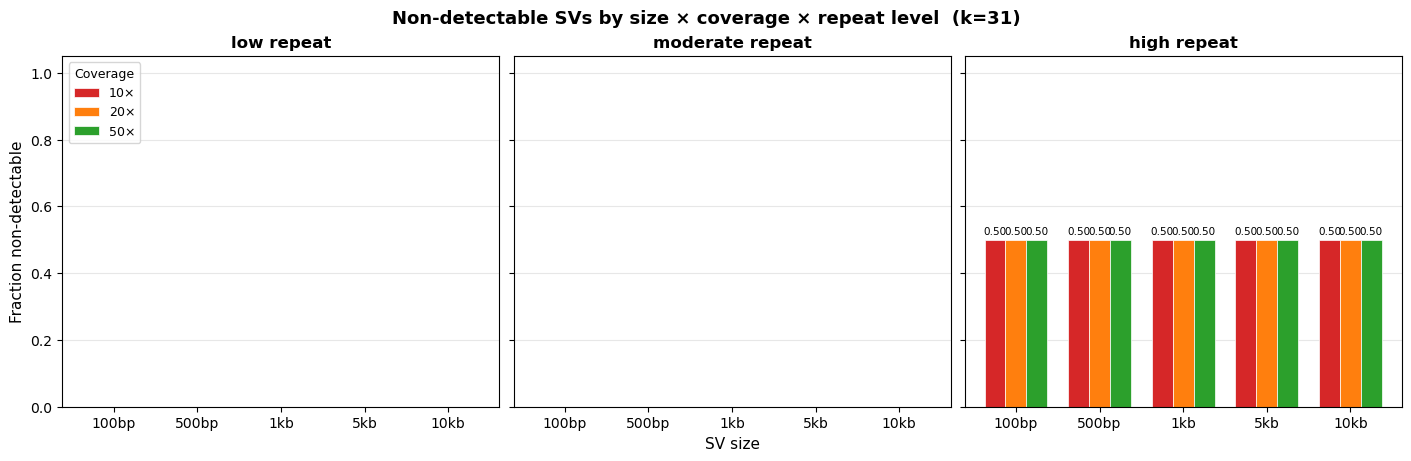

In [6]:
df = sel_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5),
                         sharey=True, constrained_layout=True)

x     = np.arange(len(SIZE_ORDER))
width = 0.25

for ax, rtype in zip(axes, REGION_ORDER):
    sub = df[df['region_type'] == rtype]
    for i, cov in enumerate(COV_ORDER):
        rates = []
        for s in SIZE_ORDER:
            sss = sub[(sub['size'] == s) & (sub['coverage'] == cov)]
            rates.append(1 - sss['detected'].mean() if len(sss) else np.nan)
        offset = (i - 1) * width
        bars = ax.bar(x + offset, rates, width,
                      color=COV_COLORS[cov], label=f'{cov}×',
                      edgecolor='white', linewidth=0.5)
        for b, r in zip(bars, rates):
            if not np.isnan(r) and r > 0.02:
                ax.text(b.get_x() + b.get_width() / 2, r + 0.01,
                        f'{r:.2f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(SIZE_ORDER, fontsize=10)
    ax.set_title(rtype, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Fraction non-detectable', fontsize=11)
axes[1].set_xlabel('SV size', fontsize=11)
axes[0].legend(title='Coverage', fontsize=9, title_fontsize=9, loc='upper left')

fig.suptitle('Non-detectable SVs by size × coverage × repeat level  (k=31)',
             fontsize=13, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/slide_nondetectable_bars.pdf', bbox_inches='tight')
plt.savefig(f'{PLOT_DIR}/slide_nondetectable_bars.png', bbox_inches='tight', dpi=300)
plt.show()

## Slide 14 (diagnostic) — Performance vs continuous repeat score

Combines `results_rep.csv` and `results_var_selectedpos_w_repeatscore.csv` to get the widest range of repeat scores (0.00 – 0.90+). k=31 only, since sel_df has only k=31.

Two panels, one point per (position × coverage):
- **Detection rate** — should show a cliff at high rs.
- **R²** (end-to-end, non-detected imputed as AF=0) — the honest accuracy per position.

Replaces the arbitrary low/moderate/high bucketing with the real continuous relationship.

In [ ]:
# ── Combine rep_df + sel_df (k=31 only) ───────────────────────────────────────
a = rep_df[rep_df['k_label'] == 'k31'][
    ['rep_id', 'coverage', 'size', 'freq_nominal',
     'af_alt', 'abs_error', 'global_repeat_score', 'detected']
].rename(columns={'rep_id': 'pos', 'global_repeat_score': 'rs'})
a['source'] = 'rep_df'

b = sel_df[sel_df['k_label'] == 'k31'][
    ['pos_label', 'coverage', 'size', 'freq_nominal',
     'af_alt', 'abs_error', 'repeat_score', 'detected']
].rename(columns={'pos_label': 'pos', 'repeat_score': 'rs'})
b['source'] = 'sel_df'

combined = pd.concat([a, b], ignore_index=True)
combined['af_alt_imputed'] = combined['af_alt'].fillna(0.0)

# Per (position × coverage) summary — detection rate + end-to-end R²
# R² = 1 − SSres/SStot (coefficient of determination).
rows = []
for (pos, cov), g in combined.groupby(['pos', 'coverage']):
    rs  = g['rs'].iloc[0]
    det = g['detected'].mean()
    y_true = g['freq_nominal'].values
    y_pred = g['af_alt_imputed'].values
    if len(y_true) < 2 or np.var(y_true) == 0:
        r2_raw = np.nan
    else:
        ss_res = ((y_true - y_pred) ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        r2_raw = 1.0 - ss_res / ss_tot
    r2_clamped = np.nan if np.isnan(r2_raw) else max(0.0, r2_raw)
    rows.append({'pos': pos, 'coverage': cov, 'rs': rs,
                 'detection_rate': det, 'r2': r2_clamped, 'r2_raw': r2_raw,
                 'n': len(g)})
summary = pd.DataFrame(rows)

neg = summary[summary['r2_raw'] < 0]
if len(neg):
    print(f"{len(neg)} (position × coverage) combos had R² < 0 (clamped to 0 for display):")
    print(neg[['pos', 'coverage', 'rs', 'detection_rate', 'r2_raw']].to_string(index=False))
    print()

# symlog x-axis: linear below LINTHRESH, log above.
# Spreads the rs<0.2 cluster while keeping the gap to rs≈0.93 compact.
LINTHRESH = 0.02

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for cov in COV_ORDER:
    s = summary[summary['coverage'] == cov]
    axes[0].scatter(s['rs'], s['detection_rate'],
                    color=COV_COLORS[cov], s=60, alpha=0.8,
                    edgecolors='white', linewidths=0.5,
                    label=f'{cov}×', zorder=3)
    axes[1].scatter(s['rs'], s['r2'],
                    color=COV_COLORS[cov], s=60, alpha=0.8,
                    edgecolors='white', linewidths=0.5,
                    label=f'{cov}×', zorder=3)

# Reference lines for the (arbitrary) bucket thresholds
for ax in axes:
    ax.set_xscale('symlog', linthresh=LINTHRESH)
    ax.set_xlim(-0.003, 1.2)
    ax.axvline(0.10, color='0.6', ls=':', lw=0.8, zorder=1)
    ax.axvline(0.50, color='0.6', ls=':', lw=0.8, zorder=1)
    ax.axvspan(-0.003, LINTHRESH, color='0.92', alpha=0.4, zorder=0)
    ax.text(LINTHRESH * 1.05, 0.02, 'log scale →', fontsize=7,
            color='0.4', va='bottom', ha='left',
            transform=ax.get_xaxis_transform())

axes[0].set_xlabel('Global repeat score (symlog)', fontsize=11)
axes[0].set_ylabel('Detection rate', fontsize=11)
axes[0].set_title('Detection rate vs repeat score', fontsize=12, fontweight='bold')
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(title='Coverage', fontsize=9, title_fontsize=9, loc='lower left')
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Global repeat score (symlog)', fontsize=11)
axes[1].set_ylabel('R² (1−SSres/SStot; clamped to ≥0)', fontsize=11)
axes[1].set_title('R² vs repeat score  (non-detected imputed as AF=0)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(title='Coverage', fontsize=9, title_fontsize=9, loc='lower left')
axes[1].grid(alpha=0.3)

fig.suptitle('freqk performance vs continuous repeat score  '
             f'({summary["pos"].nunique()} positions, k=31)',
             fontsize=13, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/slide_rs_continuous.pdf', bbox_inches='tight')
plt.savefig(f'{PLOT_DIR}/slide_rs_continuous.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nCombined summary: {len(summary)} (position × coverage) rows "
      f"across {summary['pos'].nunique()} distinct positions, "
      f"rs range {summary['rs'].min():.3f}–{summary['rs'].max():.3f}")

## Slide 15 — Chr1 repeat-score distribution

Shows that most of Chr1 is non-repetitive and the high-rs windows (centromere) are a small tail of the distribution.

Scans Chr1 in 10 kb windows (step 5 kb, k=31), computes global repeat score per window, plots the histogram + ECDF. Overlays the registered/selected positions so the audience sees where the simulated SVs sit on the chromosome's actual rs distribution.

**Note**: takes ~30 s to build the genome-wide k-mer set on first run.

Loaded cached scan: 6,053 windows


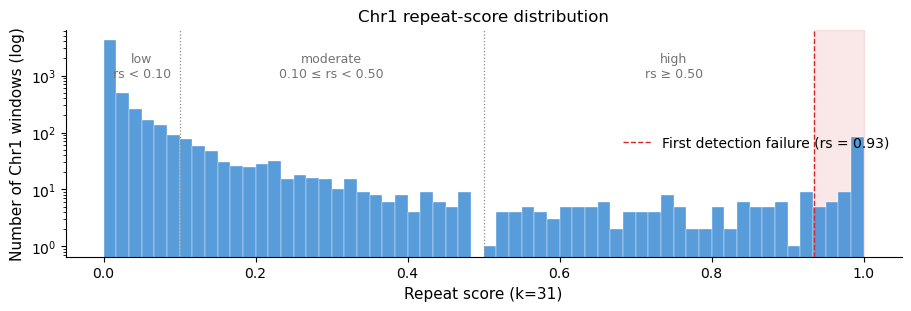


Chr1 rs distribution (6,053 windows):
  median       : 0.003
  90th pctl    : 0.119
  99th pctl    : 0.995
  max          : 1.000

Bucket breakdown:
  low  (rs < 0.10)         :  88.6%  of Chr1
  mod  (0.10 ≤ rs < 0.50)  :   7.9%
  high (rs ≥ 0.50)         :   3.6%

Detection threshold from simulations: rs = 0.934
  Chr1 below threshold (freqk works): 98.3%
  Chr1 above threshold (freqk fails): 1.7%


In [26]:
# ── Chr1 rs distribution (genome-wide scan) ───────────────────────────────────
from Bio import SeqIO

FASTA  = '../data/reference/Chr1.fa'
WINDOW = 10_000
STEP   = 5_000
K      = 31

def build_repeat_set(ref_seq, k=K):
    seen, rep = set(), set()
    s = ref_seq.replace('N', '')
    for i in range(len(s) - k + 1):
        km = s[i:i+k]
        if km in seen:
            rep.add(km)
        else:
            seen.add(km)
    del seen
    return frozenset(rep)

def rs_window(seq, rs_set, k=K):
    s = seq.replace('N', '')
    tot = len(s) - k + 1
    if tot <= 0:
        return np.nan
    return sum(1 for i in range(tot) if s[i:i+k] in rs_set) / tot

CACHE = f'{PLOT_DIR}/.chr1_rs_scan.npz'
if os.path.exists(CACHE):
    z = np.load(CACHE)
    scores = z['scores']
    print(f'Loaded cached scan: {len(scores):,} windows')
else:
    print('Building Chr1 k-mer repeat set (~30 s) …', flush=True)
    seq = str(next(SeqIO.parse(FASTA, 'fasta')).seq).upper()
    rs_set = build_repeat_set(seq)
    print(f'  {len(rs_set):,} multi-copy k-mers')
    mids_l, scores_l = [], []
    for i in range(0, len(seq) - WINDOW, STEP):
        w = seq[i:i+WINDOW]
        if w.count('N') / WINDOW > 0.5:
            continue
        mids_l.append(i + WINDOW // 2)
        scores_l.append(rs_window(w, rs_set))
    scores = np.array(scores_l)
    np.savez(CACHE, mids=np.array(mids_l), scores=scores)
    print(f'Cached to {CACHE}')

# Detection threshold from the continuous-rs summary
det_fail = summary[summary['detection_rate'] < 1.0]['rs']
RS_FIRST_FAIL = det_fail.min() if len(det_fail) else np.nan

# Repeat-level bucket boundaries (match REGION_ORDER used in heatmap/bar plots)
RS_LOW_MAX = 0.10   # low      : rs < 0.10
RS_MOD_MAX = 0.50   # moderate : 0.10 ≤ rs < 0.50
                    # high     : rs ≥ 0.50

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)

ax.hist(scores, bins=60, color='#3B8BD4', edgecolor='white',
        linewidth=0.3, alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('Repeat score (k=31)', fontsize=11)
ax.set_ylabel('Number of Chr1 windows (log)', fontsize=11)
ax.set_title('Chr1 repeat-score distribution', fontsize=12)

# Low / moderate / high bucket boundaries
for x in [RS_LOW_MAX, RS_MOD_MAX]:
    ax.axvline(x, color='0.55', ls=':', lw=0.9, zorder=2)

# Bucket labels placed along the top of the plot area (axes-fraction y)
ax.text(RS_LOW_MAX / 2, 0.90,
        'low\nrs < 0.10',
        transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=9, color='0.45')
ax.text((RS_LOW_MAX + RS_MOD_MAX) / 2, 0.90,
        'moderate\n0.10 ≤ rs < 0.50',
        transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=9, color='0.45')
ax.text((RS_MOD_MAX + 1.0) / 2, 0.90,
        'high\nrs ≥ 0.50',
        transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=9, color='0.45')

if not np.isnan(RS_FIRST_FAIL):
    ax.axvspan(RS_FIRST_FAIL, 1.0, color='#d62728', alpha=0.10, zorder=0)
    ax.axvline(RS_FIRST_FAIL, color='#d62728', lw=1, ls='--', zorder=4,
               label=f'First detection failure (rs = {RS_FIRST_FAIL:.2f})')
    ax.legend(loc='center right', fontsize=10, frameon=False)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)

plt.savefig(f'{PLOT_DIR}/slide_chr1_rs_distribution.pdf', bbox_inches='tight')
plt.savefig(f'{PLOT_DIR}/slide_chr1_rs_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

# ── Print the stats instead of overlaying them ────────────────────────────────
pct_low  = (scores < RS_LOW_MAX).mean() * 100
pct_mod  = ((scores >= RS_LOW_MAX) & (scores < RS_MOD_MAX)).mean() * 100
pct_high = (scores >= RS_MOD_MAX).mean() * 100

print(f"\nChr1 rs distribution ({len(scores):,} windows):")
print(f"  median       : {np.median(scores):.3f}")
print(f"  90th pctl    : {np.quantile(scores, 0.90):.3f}")
print(f"  99th pctl    : {np.quantile(scores, 0.99):.3f}")
print(f"  max          : {scores.max():.3f}")
print(f"\nBucket breakdown:")
print(f"  low  (rs < 0.10)         : {pct_low:5.1f}%  of Chr1")
print(f"  mod  (0.10 ≤ rs < 0.50)  : {pct_mod:5.1f}%")
print(f"  high (rs ≥ 0.50)         : {pct_high:5.1f}%")
if not np.isnan(RS_FIRST_FAIL):
    frac_below = (scores < RS_FIRST_FAIL).mean() * 100
    frac_above = (scores >= RS_FIRST_FAIL).mean() * 100
    print(f"\nDetection threshold from simulations: rs = {RS_FIRST_FAIL:.3f}")
    print(f"  Chr1 below threshold (freqk works): {frac_below:.1f}%")
    print(f"  Chr1 above threshold (freqk fails): {frac_above:.1f}%")

## Files written

- `../plots/slide_hero_cov50_lowrepeat.{pdf,png}`
- `../plots/slide_kmer_cov10.{pdf,png}`
- `../plots/slide_coverage_sweep.{pdf,png}`
- `../plots/slide_summary_heatmaps.{pdf,png}`
- `../plots/slide_nondetectable_bars.{pdf,png}`
- `../plots/slide_rs_continuous.{pdf,png}`

Drop the PNGs straight into the slide deck.